In [56]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from preprocessing.preprocess import preprocess
from models.knn import KNNClassifier

## Dataset and Goal

We use the MNIST dataset, which contains handwritten digit images from 0 to 9.

The goal of this model is binary classification:
- class 1 → digit 1
- class 0 → all other digits

The preprocessing pipeline handles loading the dataset, encoding labels, normalizing pixel values, extracting features using PCA, and splitting the data into training, validation, and test sets.

In [57]:
X_tr, X_val, X_test, y_tr, y_val, y_test = preprocess(
    feature_method='pca',
    binary=True,
    positive_class=1
)

print("Train:", X_tr.shape, y_tr.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

 Starting Preprocessing Pipeline...
   Feature method : pca
   Mode           : Binary

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Labels encoded — Positive class: Digit 1
   Training — Positive samples : 6742
   Training — Negative samples : 53258
   Test     — Positive samples : 1135
   Test     — Negative samples : 8865

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using PCA...
 Images flattened successfully!
   Training shape : (60000, 784)
   Test shape     : (10000, 784)
PCA applied successfully!
   Components kept    : 50
   Training shape     : (60000, 50)
   Test shape         : (10000, 50)
   Variance explained : 82.46%

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standar

In [58]:
X_tr_small = X_tr[:5000]
y_tr_small = y_tr[:5000]

X_val_small = X_val[:1000]
y_val_small = y_val[:1000]

K-Nearest Neighbors (KNN) is a simple algorithm that classifies a data point based on the majority label of its nearest neighbors.

The parameter **k** represents the number of nearest neighbors used for classification.

- Small k → more sensitive to noise  
- Larger k → more stable but may reduce accuracy  

Here we create the KNN model using the selected best value of **k = 1**.

In [59]:
knn = KNNClassifier(k=1)

In this step, the KNN model stores the training data and labels.
Unlike some other algorithms, KNN does not learn weights during training. Instead, it keeps the training samples and compares new points to them during prediction

In [ ]:
knn.fit(X_tr, y_tr)

The test set is used to measure the final performance of the selected model on unseen data after selecting the best value of K

This gives the final unbiased evaluation of the KNN classifier.

In [61]:
y_val_pred = knn.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))
print(confusion_matrix(y_val, y_val_pred))

Accuracy: 0.987
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     10678
           1       0.90      0.99      0.94      1322

    accuracy                           0.99     12000
   macro avg       0.95      0.99      0.97     12000
weighted avg       0.99      0.99      0.99     12000

[[10536   142]
 [   14  1308]]


The model achieved the best performance with **k = 1**, providing the highest accuracy and precision.

- **Precision** measures how many predicted positives are actually correct.  
- **Recall** measures how many actual positives are correctly detected.  

The model achieved high recall, meaning it successfully detects most digit 1 images.

From the confusion matrix:
- Very few false negatives → the model rarely misses digit 1  
- Some false positives → the model sometimes predicts 1 incorrectly  

Overall, the model performs very well and is effective for this classification task.

In [62]:
y_test_pred = knn.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))

Test Accuracy: 0.9886
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      8865
           1       0.91      0.99      0.95      1135

    accuracy                           0.99     10000
   macro avg       0.96      0.99      0.97     10000
weighted avg       0.99      0.99      0.99     10000

[[8759  106]
 [   8 1127]]


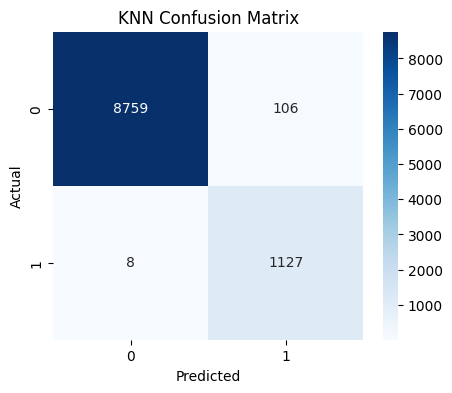

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("../results/knn_confusion_matrix.png")  # IMPORTANT path
plt.show()

In [64]:
from sklearn.metrics import accuracy_score, classification_report

with open("../results/knn_results.txt", "w") as f:
    f.write("Test Accuracy: " + str(accuracy_score(y_test, y_test_pred)) + "\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(y_test, y_test_pred))